# EEG Driver Safety

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
  )

# Reduce TensorFlow log noise (must be set before importing TF)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # 0=all, 1=INFO off, 2=WARNING off, 3=ERROR only
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [74]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.20  # fraction of train split used for validation
DATA_PATH = Path("Dataset.csv")

def set_seeds(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

## Load `Dataset.csv` and Basic Validation

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

expected_cols = [
    "attention", "meditation", "delta", "theta", "lowAlpha", "highAlpha",
    "lowBeta", "highBeta", "lowGamma", "highGamma", "classification"
]
missing_expected = [c for c in expected_cols if c not in df.columns]

# Basic checks
print("Dtypes:")
display(df.dtypes)

dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)
if dup_count:
    df = df.drop_duplicates().reset_index(drop=True)
    print("After dropping duplicates:", df.shape)

# Sanity: non-negative band powers
power_cols = ["delta","theta","lowAlpha","highAlpha","lowBeta","highBeta","lowGamma","highGamma"]
neg_counts = (df[power_cols] < 0).sum().sum()
print("Negative power entries:", int(neg_counts))

# Sanity: target is binary-ish
unique_y = sorted(df["classification"].dropna().unique().tolist())
print("Unique labels:", unique_y)

Shape: (3735, 11)


,attention,meditation,delta,theta,lowAlpha,highAlpha,lowBeta,highBeta,lowGamma,highGamma,classification
0,26,34,960462,277180,26575,27356,26575,13056,9126,2683,0
1,29,54,39145,28225,20172,39551,20172,9933,5237,4750,0
2,40,48,75410,43144,8601,13564,8601,11663,2515,3251,0
3,66,47,16057,41211,2534,34254,2534,27663,11396,2825,0
4,81,67,10304,47239,33158,47349,33158,16328,5298,5471,0


Dtypes:


attention         int64
meditation        int64
delta             int64
theta             int64
lowAlpha          int64
highAlpha         int64
lowBeta           int64
highBeta          int64
lowGamma          int64
highGamma         int64
classification    int64
dtype: object

Duplicate rows: 0
Negative power entries: 0
Unique labels: [0, 1]


## Data Analysis (EDA): Schema, Summary Stats, Missingness

In [76]:
display(df.info())
display(df.describe().T)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)
missing_df = pd.DataFrame({"missing": missing, "missing_pct": missing_pct})
display(missing_df[missing_df["missing"] > 0])

if (missing > 0).any():
    plt.figure(figsize=(10, 3))
    sns.heatmap(df.isna(), cbar=False)
    plt.title("Missingness heatmap")
    plt.show()
else:
    print("No missing values detected.")

<class 'pandas.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   attention       3735 non-null   int64
 1   meditation      3735 non-null   int64
 2   delta           3735 non-null   int64
 3   theta           3735 non-null   int64
 4   lowAlpha        3735 non-null   int64
 5   highAlpha       3735 non-null   int64
 6   lowBeta         3735 non-null   int64
 7   highBeta        3735 non-null   int64
 8   lowGamma        3735 non-null   int64
 9   highGamma       3735 non-null   int64
 10  classification  3735 non-null   int64
dtypes: int64(11)
memory usage: 321.1 KB


None

,count,mean,std,min,25%,50%,75%,max
attention,3735.0,48.214726,21.876949,1.0,35.0,48.0,63.0,100.0
meditation,3735.0,56.577510,19.066577,1.0,43.0,56.0,69.0,100.0
delta,3735.0,518771.389290,599783.663336,216.0,71996.5,277382.0,778068.0,3598743.0
theta,3735.0,136242.001874,217550.078075,138.0,23472.0,57972.0,151485.5,3194358.0
lowAlpha,3735.0,33413.343775,51970.930842,32.0,7402.0,16481.0,37721.5,699008.0
highAlpha,3735.0,30580.759036,52681.858764,9.0,6908.5,14928.0,33147.5,785947.0
lowBeta,3735.0,25640.069076,37159.039642,2.0,6240.0,13841.0,30236.0,595549.0
highBeta,3735.0,23276.979384,43921.116122,3.0,4862.0,9739.0,20796.5,443589.0
lowGamma,3735.0,8117.130388,15522.904383,6.0,2247.0,4440.0,8813.0,289281.0
highGamma,3735.0,208725.809906,329707.322778,47.0,5683.0,57198.0,257687.5,2328370.0


,missing,missing_pct


No missing values detected.


## EDA: Target Balance, Distributions, and Outliers

,count,proportion
classification,,
0,2135,0.572
1,1600,0.428


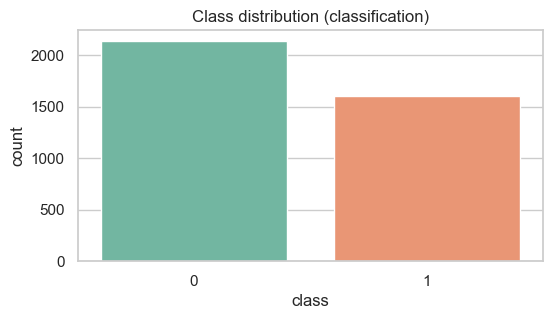

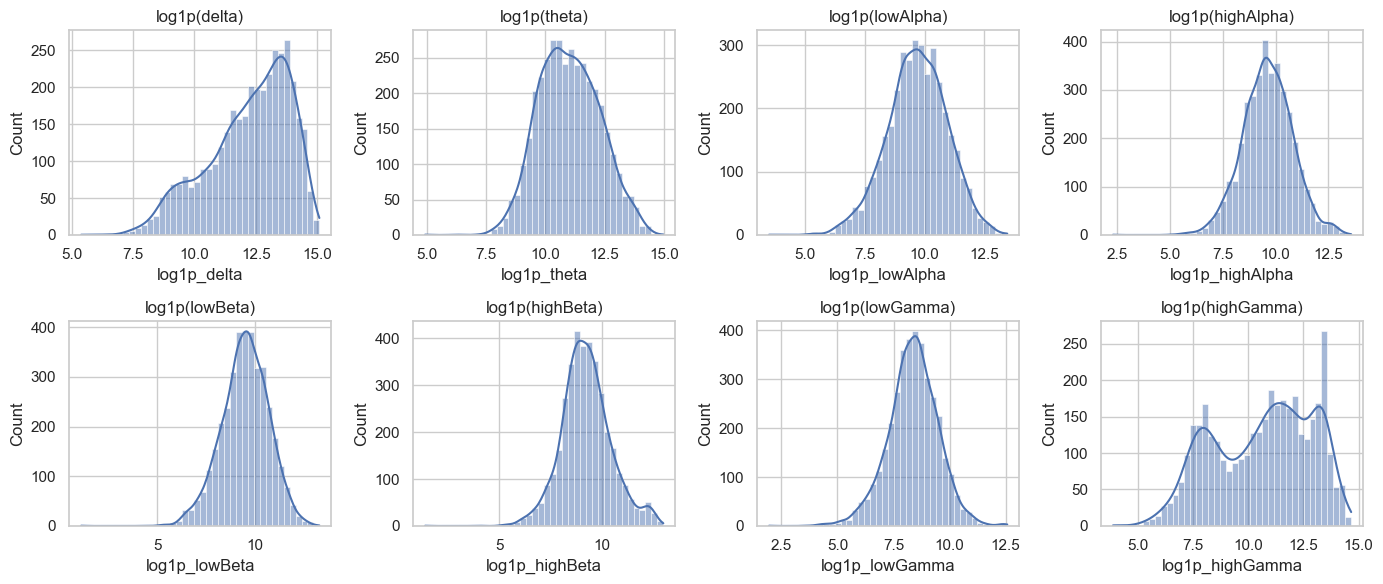

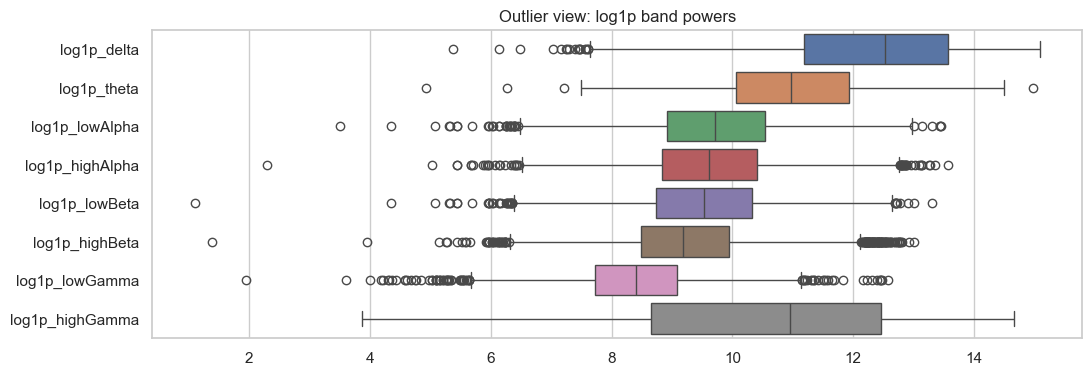

In [77]:
target = df["classification"].astype(int)
class_counts = target.value_counts().sort_index()
class_props = (class_counts / len(df)).round(3)
display(pd.DataFrame({"count": class_counts, "proportion": class_props}))

plt.figure(figsize=(6, 3))
sns.countplot(x=target, hue=target, palette="Set2", legend=False)
plt.title("Class distribution (classification)")
plt.xlabel("class")
plt.ylabel("count")
plt.show()

# Feature distributions (raw + log-scale for power bands)
feature_cols = [c for c in df.columns if c != "classification"]

df_plot = df.copy()
for c in power_cols:
    df_plot[f"log1p_{c}"] = np.log1p(df_plot[c])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axes.ravel(), power_cols):
    sns.histplot(df_plot[f"log1p_{c}"], bins=40, kde=True, ax=ax)
    ax.set_title(f"log1p({c})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.boxplot(data=df_plot[[f"log1p_{c}" for c in power_cols]], orient="h")
plt.title("Outlier view: log1p band powers")
plt.show()

## EDA: Correlation / Multicollinearity

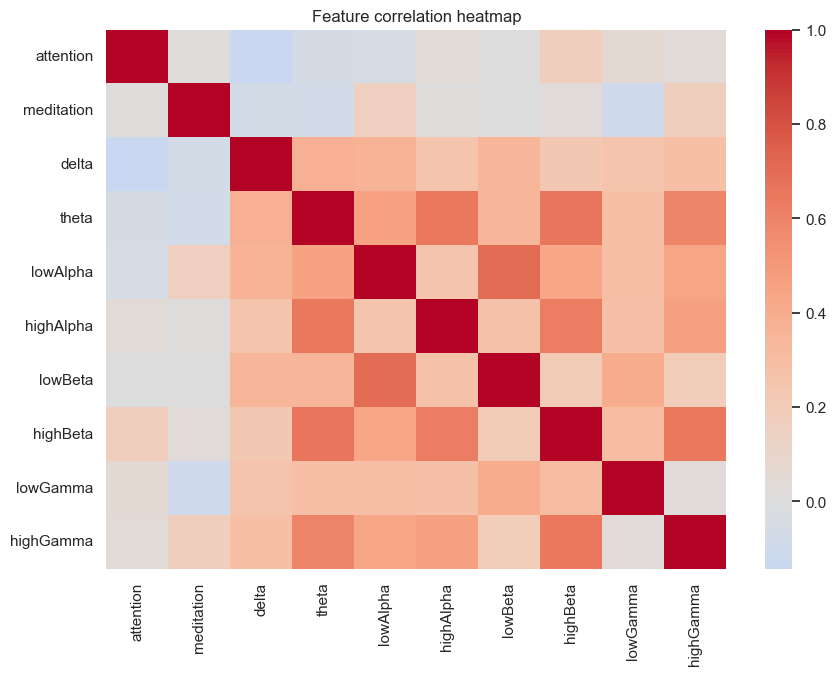

,feat1,feat2,abs_corr
0,lowAlpha,lowBeta,0.693183
1,theta,highBeta,0.663608
2,theta,highAlpha,0.656068
3,highBeta,highGamma,0.650842
4,highAlpha,highBeta,0.632582
5,theta,highGamma,0.594448
6,highAlpha,highGamma,0.469033
7,theta,lowAlpha,0.456296
8,lowAlpha,highGamma,0.444335
9,lowAlpha,highBeta,0.437718


In [78]:
corr = df[feature_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

# Show strongest absolute correlations (excluding self-corr)
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
top_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={"level_0": "feat1", "level_1": "feat2", 0: "abs_corr"})
)
display(top_pairs)

## Data Preprocessing: Train / Validation / Test Split (Stratified)

In [79]:
X = df.drop(columns=["classification"])
y = df["classification"].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
 )
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train_full
 )

print("Train:", X_train.shape, y_train.mean().round(3))
print("Val  :", X_val.shape, y_val.mean().round(3))
print("Test :", X_test.shape, y_test.mean().round(3))

Train: (2390, 10) 0.428
Val  : (598, 10) 0.428
Test : (747, 10) 0.428


## Feature Extraction: Domain Ratios + Normalized Band-Power Features
We engineer a few standard EEG-inspired ratios/indices and relative band powers. This is deterministic (no learned parameters) and is applied consistently to train/val/test.

In [ ]:
def engineer_features(X_df: pd.DataFrame) -> pd.DataFrame:
    X_df = X_df.copy()
    eps = 1e-9

    # Log-transform band powers to tame heavy tails
    for c in power_cols:
        X_df[f"log1p_{c}"] = np.log1p(X_df[c].clip(lower=0))

    # Total power (raw) + relative powers (raw)
    total_power = X_df[power_cols].sum(axis=1) + eps
    X_df["total_power"] = total_power
    for c in power_cols:
        X_df[f"rel_{c}"] = X_df[c] / total_power

    # Grouped bands
    alpha = X_df["lowAlpha"] + X_df["highAlpha"] + eps
    beta = X_df["lowBeta"] + X_df["highBeta"] + eps
    gamma = X_df["lowGamma"] + X_df["highGamma"] + eps
    theta = X_df["theta"] + eps

    # Common ratios/indices
    X_df["theta_alpha"] = theta / alpha
    X_df["beta_alpha"] = beta / alpha
    X_df["gamma_beta"] = gamma / beta
    X_df["theta_beta"] = theta / beta
    X_df["engagement_index"] = beta / (alpha + theta)
    X_df["attention_x_meditation"] = X_df["attention"] * X_df["meditation"]

    # Keep only numeric columns (safe)
    return X_df.select_dtypes(include=[np.number])

X_train_eng = engineer_features(X_train)
X_val_eng = engineer_features(X_val)
X_test_eng = engineer_features(X_test)

print("Engineered feature shape:")
print("Train:", X_train_eng.shape, "Val:", X_val_eng.shape, "Test:", X_test_eng.shape)
display(X_train_eng.head())

Engineered feature shape:
Train: (2390, 33) Val: (598, 33) Test: (747, 33)


,attention,meditation,delta,theta,lowAlpha,highAlpha,lowBeta,highBeta,lowGamma,highGamma,...,rel_lowBeta,rel_highBeta,rel_lowGamma,rel_highGamma,theta_alpha,beta_alpha,gamma_beta,theta_beta,engagement_index,attention_x_meditation
3622,29,60,1002892,17729,10642,8035,10642,2039,1817,788,...,0.010091,0.001933,0.001723,0.000747,0.949242,0.678963,0.205425,1.398076,0.348322,1740
155,53,51,898800,123621,26508,39354,26508,9252,4439,2945,...,0.023429,0.008177,0.003923,0.002603,1.876970,0.542953,0.206488,3.456963,0.188724,2703
2202,38,77,843755,193461,86711,62864,86711,21132,16138,557135,...,0.046421,0.011313,0.008640,0.298267,1.293405,0.720996,5.315811,1.793913,0.314378,2926
3666,43,83,499410,126560,105884,63191,105884,56864,12582,24106,...,0.106472,0.057180,0.012652,0.024240,0.748544,0.962579,0.225428,0.777644,0.550503,3569
3636,53,50,106813,33192,4080,7680,4080,4603,1227,561,...,0.025149,0.028372,0.007563,0.003458,2.822449,0.738350,0.205920,3.822642,0.193162,2650


## Feature Extraction: Feature Ranking and Optional Dimensionality Reduction (Mutual Info, PCA)

,mutual_info
log1p_highGamma,0.104525
highGamma,0.103867
total_power,0.057206
theta,0.052438
log1p_theta,0.052232
delta,0.052081
log1p_delta,0.051701
gamma_beta,0.035296
highAlpha,0.032222
log1p_highAlpha,0.031755


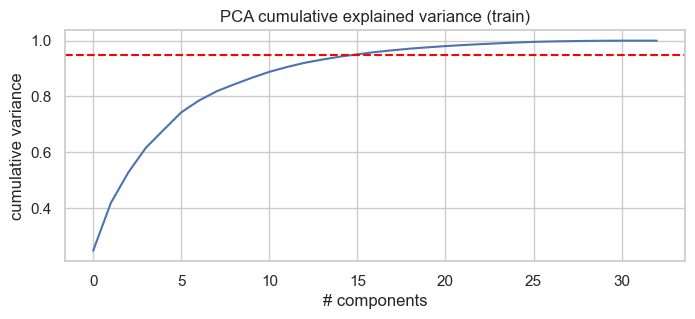

Components for >=95% variance: 16


In [81]:
# Mutual information feature ranking (on training only)
mi = mutual_info_classif(X_train_eng, y_train, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=X_train_eng.columns).sort_values(ascending=False)
display(mi_s.head(20).to_frame("mutual_info"))

# PCA explained variance (after scaling)
scaler_tmp = StandardScaler()
X_train_scaled_tmp = scaler_tmp.fit_transform(X_train_eng)
pca_tmp = PCA().fit(X_train_scaled_tmp)
cum_var = np.cumsum(pca_tmp.explained_variance_ratio_)

plt.figure(figsize=(8, 3))
plt.plot(cum_var)
plt.axhline(0.95, color="red", linestyle="--")
plt.title("PCA cumulative explained variance (train)")
plt.xlabel("# components")
plt.ylabel("cumulative variance")
plt.show()

n95 = int(np.argmax(cum_var >= 0.95) + 1)
print("Components for >=95% variance:", n95)

In [82]:
def evaluate_probs(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
    }

def plot_confusion(y_true: np.ndarray, y_prob: np.ndarray, title: str, threshold: float = 0.5) -> None:
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

def plot_roc_curve(y_true: np.ndarray, y_prob: np.ndarray, label: str) -> tuple[np.ndarray, np.ndarray, float]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
    return fpr, tpr, auc

## Model 1 — SVM (Pipeline + Hyperparameter Search)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/home/rutab/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rutab/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/rutab/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/rutab/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/rutab/.local/lib/python3.12/site-packa

Best params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV ROC-AUC: 0.8315813918999627
SVM validation metrics: {'accuracy': 0.7809364548494984, 'precision': 0.751004016064257, 'recall': 0.73046875, 'f1': 0.7405940594059406, 'roc_auc': 0.8594435307017543}
SVM test metrics: {'accuracy': 0.7764390896921017, 'precision': 0.7459807073954984, 'recall': 0.725, 'f1': 0.7353407290015848, 'roc_auc': 0.8623572892271664}

SVM test classification report:

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       427
           1       0.75      0.72      0.74       320

    accuracy                           0.78       747
   macro avg       0.77      0.77      0.77       747
weighted avg       0.78      0.78      0.78       747



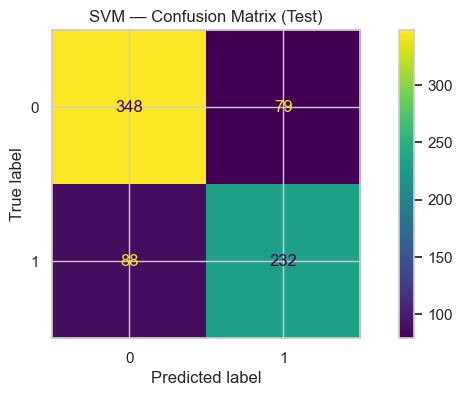

In [83]:
svm_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("select", "passthrough"),
    ("pca", "passthrough"),
    ("svm", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
])

param_grid = [
    # Baseline
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1],
    },
    # With SelectKBest
    {
        "select": [SelectKBest(mutual_info_classif)],
        "select__k": [10, 20, 30, "all"],
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1],
    },
    # With PCA
    {
        "pca": [PCA()],
        "pca__n_components": [0.90, 0.95, 0.99],
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1],
    },
]

grid = GridSearchCV(
    svm_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train_eng, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_svm = grid.best_estimator_
svm_val_prob = best_svm.predict_proba(X_val_eng)[:, 1]
svm_test_prob = best_svm.predict_proba(X_test_eng)[:, 1]

svm_val_metrics = evaluate_probs(y_val.values, svm_val_prob)
svm_test_metrics = evaluate_probs(y_test.values, svm_test_prob)
print("SVM validation metrics:", svm_val_metrics)
print("SVM test metrics:", svm_test_metrics)

print("\nSVM test classification report:\n")
print(classification_report(y_test, (svm_test_prob >= 0.5).astype(int)))

plot_confusion(y_test.values, svm_test_prob, title="SVM — Confusion Matrix (Test)")

## Model 2 — 1D CNN on Engineered Feature “Sequence”

Class weight: {0: 0.8748169838945827, 1: 1.1669921875}


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 33, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 33, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 33, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 33, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - acc: 0.5686 - auc: 0.5960 - loss: 0.7164 - val_acc: 0.6371 - val_auc: 0.7059 - val_loss: 0.6829 - learning_rate: 0.0010
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6234 - auc: 0.6754 - loss: 0.6465 - val_acc: 0.6438 - val_auc: 0.7125 - val_loss: 0.6752 - learning_rate: 0.0010
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6201 - auc: 0.6765 - loss: 0.6480 - val_acc: 0.6706 - val_auc: 0.7347 - val_loss: 0.6629 - learning_rate: 0.0010
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6331 - auc: 0.6890 - loss: 0.6413 - val_acc: 0.6806 - val_auc: 0.7463 - val_loss: 0.6521 - learning_rate: 0.0010
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6406 - auc: 0.7020 - loss: 0.6305 - val_acc: 0.6672 - val_auc: 0.7417 - val_loss: 0.6429 - learning_rate: 0.0010
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.6515 - auc: 0.7096 - loss: 0.6229 - val_acc: 0.6773 - val_auc: 0.7436 - val_loss

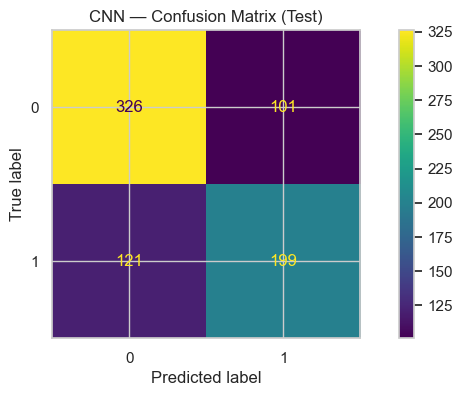

In [84]:
from sklearn.utils.class_weight import compute_class_weight

feature_names = X_train_eng.columns.tolist()
scaler_dl = StandardScaler()
X_train_dl = scaler_dl.fit_transform(X_train_eng)
X_val_dl = scaler_dl.transform(X_val_eng)
X_test_dl = scaler_dl.transform(X_test_eng)

n_features = X_train_dl.shape[1]
X_train_seq = X_train_dl.reshape(-1, n_features, 1)
X_val_seq = X_val_dl.reshape(-1, n_features, 1)
X_test_seq = X_test_dl.reshape(-1, n_features, 1)

classes = np.array([0, 1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print("Class weight:", class_weight)

def build_cnn(input_shape: tuple[int, int]) -> keras.Model:
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")],
    )
    return model

cnn = build_cnn((n_features, 1))
cnn.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=5, min_lr=1e-5),
]

history_cnn = cnn.fit(
    X_train_seq, y_train.values,
    validation_data=(X_val_seq, y_val.values),
    epochs=50,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

cnn_val_prob = cnn.predict(X_val_seq).ravel()
cnn_test_prob = cnn.predict(X_test_seq).ravel()

cnn_val_metrics = evaluate_probs(y_val.values, cnn_val_prob)
cnn_test_metrics = evaluate_probs(y_test.values, cnn_test_prob)
print("CNN validation metrics:", cnn_val_metrics)
print("CNN test metrics:", cnn_test_metrics)

print("\nCNN test classification report:\n")
print(classification_report(y_test, (cnn_test_prob >= 0.5).astype(int)))

plot_confusion(y_test.values, cnn_test_prob, title="CNN — Confusion Matrix (Test)")

## Model 3 — RNN (LSTM) on Engineered Feature “Sequence”

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 33, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.6218 - auc: 0.6573 - loss: 0.6594 - val_acc: 0.6438 - val_auc: 0.7116 - val_loss: 0.6147 - learning_rate: 0.0010
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6423 - auc: 0.7008 - loss: 0.6304 - val_acc: 0.6572 - val_auc: 0.7200 - val_loss: 0.6112 - learning_rate: 0.0010
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6506 - auc: 0.7017 - loss: 0.6296 - val_acc: 0.6555 - val_auc: 0.7254 - val_loss: 0.6070 - learning_rate: 0.0010
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6536 - auc: 0.7072 - loss: 0.6259 - val_acc: 0.6538 - val_auc: 0.7257 - val_loss: 0.6065 - learning_rate: 0.0010
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6523 - auc: 0.7026 - loss: 0.6285 - val_acc: 0.6572 - val_auc: 0.7268 - val_loss: 0.6073 - learning_rate: 0.0010
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.6494 - auc: 0.7109 - loss: 0.6225 - val_acc: 0.6672 - val_auc: 0.7300 - val_loss

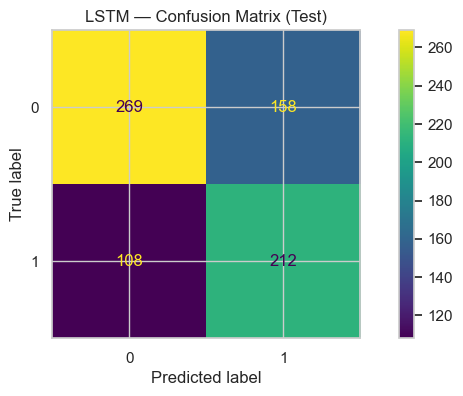

In [85]:
def build_lstm(input_shape: tuple[int, int]) -> keras.Model:
    inputs = keras.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=False)(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")],
    )
    return model

lstm = build_lstm((n_features, 1))
lstm.summary()

history_lstm = lstm.fit(
    X_train_seq, y_train.values,
    validation_data=(X_val_seq, y_val.values),
    epochs=50,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

lstm_val_prob = lstm.predict(X_val_seq).ravel()
lstm_test_prob = lstm.predict(X_test_seq).ravel()

lstm_val_metrics = evaluate_probs(y_val.values, lstm_val_prob)
lstm_test_metrics = evaluate_probs(y_test.values, lstm_test_prob)
print("LSTM validation metrics:", lstm_val_metrics)
print("LSTM test metrics:", lstm_test_metrics)

print("\nLSTM test classification report:\n")
print(classification_report(y_test, (lstm_test_prob >= 0.5).astype(int)))

plot_confusion(y_test.values, lstm_test_prob, title="LSTM — Confusion Matrix (Test)")

## Evaluation: Accuracy, Precision/Recall, F1, ROC-AUC, Confusion Matrix

In [86]:
results = pd.DataFrame([
    {"model": "SVM", **svm_test_metrics},
    {"model": "CNN", **cnn_test_metrics},
    {"model": "LSTM", **lstm_test_metrics},
]).set_index("model").sort_values("roc_auc", ascending=False)

display(results.round(4))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
SVM,0.7764,0.7460,0.7250,0.7353,0.8624
CNN,0.7028,0.6633,0.6219,0.6419,0.7843
LSTM,0.6439,0.5730,0.6625,0.6145,0.7162


## Evaluation: ROC Curves (All Models) + AUC Comparison

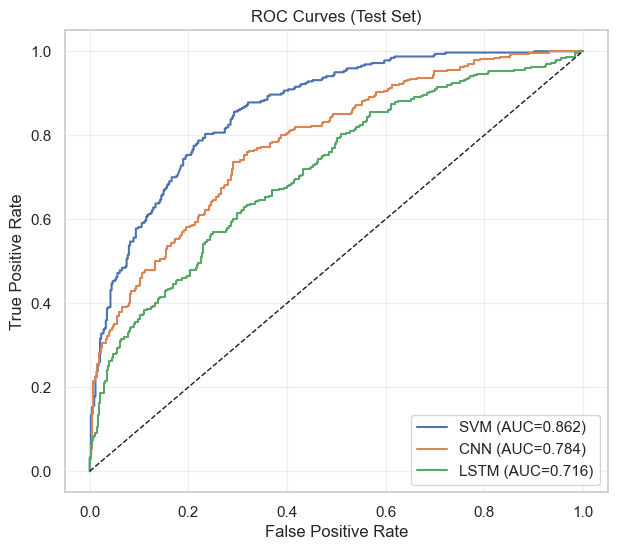

In [87]:
plt.figure(figsize=(7, 6))
plot_roc_curve(y_test.values, svm_test_prob, "SVM")
plot_roc_curve(y_test.values, cnn_test_prob, "CNN")
plot_roc_curve(y_test.values, lstm_test_prob, "LSTM")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC Curves (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()